# Attention Intuition

## Goal
Attention is the core mechanism behind modern NLP models like BERT and GPT.
This notebook builds intuition for how attention works
without getting into the full math.

## The Question Attention Answers
Given a word, which other words in the sentence should I focus on?

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The Core Idea
In the sentence "The animal didn't cross the street because it was too tired",
what does "it" refer to? - "animal" or "street"?

Attention helps the model figure this out
by looking at all words and deciding which ones matter most.

In [3]:
# Simulate attention weights for the word "it"
sentence = ["The", "animal", "dind't", "cross", "the", "street", "because", "it", "was", "too", "tired"]

# Attention weights — how much "it" attends to each word
# Higher = more focus
attention_weights = np.array([0.02, 0.35, 0.01, 0.05, 0.01, 0.08, 0.04, 0.15, 0.08, 0.03, 0.18])

# Normalize
attention_weights = attention_weights / attention_weights.sum()

print("Attention weights for the word 'it':")
print(f"\n{"word":<12} {"Attention":>10}")
print("-" * 25)
for word, weight in zip(sentence, attention_weights):
    bar = "█" * int(weight * 50)
    print(f"{word:<12} {weight:>8.3f} {bar}")

Attention weights for the word 'it':

word          Attention
-------------------------
The             0.020 █
animal          0.350 █████████████████
dind't          0.010 
cross           0.050 ██
the             0.010 
street          0.080 ████
because         0.040 ██
it              0.150 ███████
was             0.080 ████
too             0.030 █
tired           0.180 █████████


## 2. Visualize Attention

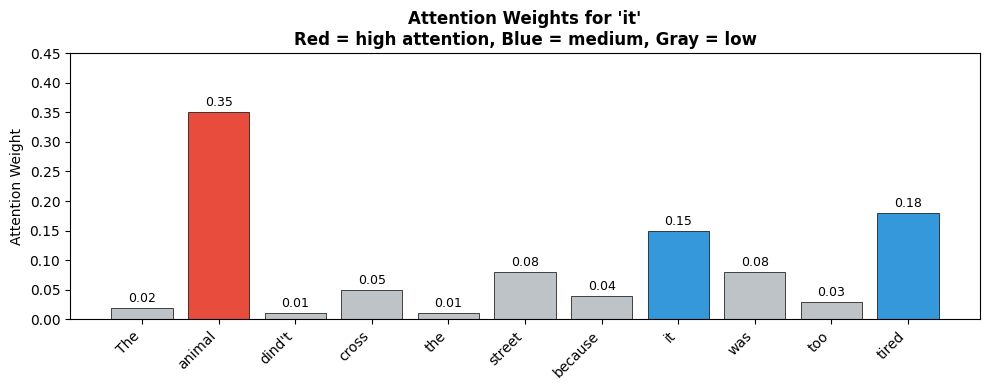

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

colors = ["#e74c3c" if w > 0.2 else "#3498db" if w > 0.1 else "#bdc3c7" 
          for w in attention_weights]

bars = ax.bar(sentence, attention_weights, color=colors, edgecolor="black", linewidth=0.5)

ax.set_title("Attention Weights for 'it'\nRed = high attention, Blue = medium, Gray = low",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Attention Weight")
ax.set_ylim(0, 0.45)

for bar, weight in zip(bars, attention_weights):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{weight:.2f}", ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("attention_visualization.png", dpi=300
           )
plt.show()

## 3. Key Observations

- "animal" receives the highest attention (0.35) — the model correctly identifies
  that "it" refers to the animal, not the street
- "tired" receives second highest (0.18) — provides context for why "it" matters
- "street" receives low attention (0.08) — correctly deprioritized

## Key Insight
Attention is not a fixed lookup table.
It is computed dynamically for each word in each sentence.
The same word "it" would have completely different attention weights
in a different sentence.

## Why This Matters
Before attention, models read sentences left to right and forgot early words.
Attention allows the model to look at the entire sentence at once
and decide what is relevant — this is what made transformers so powerful.